### 1. Keras Sequential Model for MNIST Without Regularization

#### Import Libraries and Load Dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
print(x_train.shape)

(60000, 784)


#### Create Model Without Regularization

In [2]:
model_basic = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_basic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_basic = model_basic.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9278 - loss: 0.2423 - val_accuracy: 0.9524 - val_loss: 0.1523
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9693 - loss: 0.1021 - val_accuracy: 0.9698 - val_loss: 0.0944
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9782 - loss: 0.0705 - val_accuracy: 0.9739 - val_loss: 0.0787
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9772 - val_loss: 0.0755
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0416 - val_accuracy: 0.9788 - val_loss: 0.0765


#### Store Validation Accuracy

In [3]:
basic_val_accuracy = history_basic.history['val_accuracy'][-1]
print("Validation Accuracy without Regularization:",
      basic_val_accuracy)

Validation Accuracy without Regularization: 0.9787999987602234


### 2. Add L2 Regularization

In [4]:
from tensorflow.keras import regularizers
model_l2 = keras.Sequential([
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        input_shape=(784,)
    ),
    layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01)
    ),
    layers.Dense(
        10,
        activation='softmax',
        kernel_regularizer=regularizers.l2(0.01)
    )
])
model_l2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_l2 = model_l2.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)
l2_val_accuracy = history_l2.history['val_accuracy'][-1]
print("Validation Accuracy with L2 Regularization:",
      l2_val_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8868 - loss: 1.0316 - val_accuracy: 0.9048 - val_loss: 0.8129
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9051 - loss: 0.8097 - val_accuracy: 0.9027 - val_loss: 0.7969
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9057 - loss: 0.7953 - val_accuracy: 0.9132 - val_loss: 0.7718
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9076 - loss: 0.7876 - val_accuracy: 0.9044 - val_loss: 0.7776
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9089 - loss: 0.7803 - val_accuracy: 0.9117 - val_loss: 0.7691
Validation Accuracy with L2 Regularization: 0.9117000102996826


#### Compare Results

In [5]:
print("Without Regularization:", basic_val_accuracy)
print("With L2 Regularization:", l2_val_accuracy)

Without Regularization: 0.9787999987602234
With L2 Regularization: 0.9117000102996826


### 3. Add Dropout Layers

In [6]:
model_dropout = keras.Sequential([
    layers.Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),
    layers.Dropout(0.48),
    layers.Dense(
        64,
        activation='relu'
    ),
    layers.Dropout(0.48),
    layers.Dense(
        10,
        activation='softmax'
    )
])
model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_dropout = model_dropout.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)
dropout_val_accuracy = history_dropout.history['val_accuracy'][-1]
print("Validation Accuracy with Dropout:",
      dropout_val_accuracy)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8187 - loss: 0.5901 - val_accuracy: 0.9453 - val_loss: 0.1854
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9103 - loss: 0.3205 - val_accuracy: 0.9562 - val_loss: 0.1563
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9244 - loss: 0.2708 - val_accuracy: 0.9629 - val_loss: 0.1346
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9316 - loss: 0.2414 - val_accuracy: 0.9639 - val_loss: 0.1234
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9360 - loss: 0.2258 - val_accuracy: 0.9674 - val_loss: 0.1132
Validation Accuracy with Dropout: 0.9674000144004822


### 4. Add Batch Normalization

In [7]:
model_batchnorm = keras.Sequential([
    layers.Dense(
        128,
        input_shape=(784,)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(
        64
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(
        10,
        activation='softmax'
    )
])
model_batchnorm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_batchnorm = model_batchnorm.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9287 - loss: 0.2483 - val_accuracy: 0.9643 - val_loss: 0.1143
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9640 - loss: 0.1168 - val_accuracy: 0.9751 - val_loss: 0.0827
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9722 - loss: 0.0887 - val_accuracy: 0.9749 - val_loss: 0.0762
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9785 - loss: 0.0693 - val_accuracy: 0.9754 - val_loss: 0.0782
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9813 - loss: 0.0600 - val_accuracy: 0.9775 - val_loss: 0.0703


### 5. Implement EarlyStopping

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
model_early = keras.Sequential([
    layers.Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),
    layers.Dense(
        64,
        activation='relu'
    ),
    layers.Dense(
        10,
        activation='softmax'
    )
])
model_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
history_early = model_early.fit(
    x_train,
    y_train,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9306 - loss: 0.2358 - val_accuracy: 0.9632 - val_loss: 0.1195
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9687 - loss: 0.1016 - val_accuracy: 0.9712 - val_loss: 0.0957
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9772 - loss: 0.0709 - val_accuracy: 0.9747 - val_loss: 0.0867
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9829 - loss: 0.0547 - val_accuracy: 0.9765 - val_loss: 0.0806
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9857 - loss: 0.0446 - val_accuracy: 0.9756 - val_loss: 0.0852
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9887 - loss: 0.0350 - val_accuracy: 0.9763 - val_loss: 0.0834


#### Check Number of Epochs and Accuracy

In [9]:
epochs_used = len(history_early.history['loss'])
final_accuracy = history_early.history['val_accuracy'][-1]
print("Number of epochs completed:", epochs_used)
print("Final Validation Accuracy:",
      final_accuracy)

Number of epochs completed: 6
Final Validation Accuracy: 0.9763000011444092


#### Plot EarlyStopping Training Curve

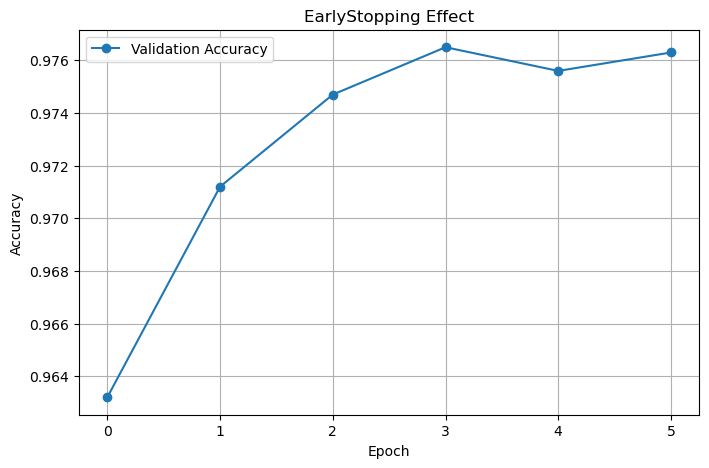

In [10]:
plt.figure(figsize=(8,5))
plt.plot(
    history_early.history['val_accuracy'],
    marker='o',
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EarlyStopping Effect")
plt.legend()
plt.grid()
plt.show()

### Quick note

The main concepts and workflow remain the same. Try changing one or two input values yourself and rerun the cells to see how the output responds.